# Proyecto EDA

## Preparación de los ficheros de datos: importación de librerías y carga de datos

In [2]:
# 1. Importación de liberías

import pandas as pd  # para manipulación de datos
import numpy as np  # para realizar operaciones numéricas

import matplotlib.pyplot as plt  # para gráficos
import seaborn as sns  # para gráficos estadísticos

plt.style.use("ggplot")
sns.set_theme()

In [3]:
# 2. Cargar los datos

# Cargamos los dos ficheros de datos de forma diferente, porque los datos del banco están en un archivo .csv y los de clientes en un archivo .xlsx

bank = pd.read_csv("C:/Users/U000000/Desktop/varios/ThePower/PROYECTO T8/data/raw/bank-additional.csv")

clientes = pd.read_excel(
    "C:/Users/U000000/Desktop/varios/ThePower/PROYECTO T8/data/raw/customer-details.xlsx",
    sheet_name=None
)

# El excel de clientes tiene tres hojas, "2012", "2013" y "2014". Las vamos a unir en un único excel.

clientes.keys()

customer = pd.concat(clientes.values(), ignore_index=True)


## Limpieza de datos

En este punto se realiza una exploración inicial de los ficheros que cargados y se lleva a cabo la limpieza de los datos.
La limpieza de datos incluye el tratamiento de los valores duplicados, de los valores nulos, cambiar tipos de datos, cambiar 0 y 1 por "Sí" y "No" o revisar las categorías de las variables.

In [4]:
# 3. Realizamos una exploración inicial de los dos ficheros de datos

bank.head()

,Unnamed: 0,age,job,marital,education,default,housing,loan,contact,duration,...,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,latitude,longitude,id_
0,0,NaN,housemaid,MARRIED,basic.4y,0.0,0.0,0.0,telephone,261,...,1.1,"93,994","-36,4","4,857",5191,no,2-agosto-2019,41.495,-71.233,089b39d8-e4d0-461b-87d4-814d71e0e079
1,1,57.0,services,MARRIED,high.school,NaN,0.0,0.0,telephone,149,...,1.1,"93,994","-36,4",NaN,5191,no,14-septiembre-2016,34.601,-83.923,e9d37224-cb6f-4942-98d7-46672963d097
2,2,37.0,services,MARRIED,high.school,0.0,1.0,0.0,telephone,226,...,1.1,"93,994","-36,4","4,857",5191,no,15-febrero-2019,34.939,-94.847,3f9f49b5-e410-4948-bf6e-f9244f04918b
3,3,40.0,admin.,MARRIED,basic.6y,0.0,0.0,0.0,telephone,151,...,1.1,"93,994","-36,4",NaN,5191,no,29-noviembre-2015,49.041,-70.308,9991fafb-4447-451a-8be2-b0df6098d13e
4,4,56.0,services,MARRIED,high.school,0.0,0.0,1.0,telephone,307,...,1.1,"93,994","-36,4",NaN,5191,no,29-enero-2017,38.033,-104.463,eca60b76-70b6-4077-80ba-bc52e8ebb0eb


In [5]:
bank.info()

<class 'pandas.DataFrame'>
RangeIndex: 43000 entries, 0 to 42999
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      43000 non-null  int64  
 1   age             37880 non-null  float64
 2   job             42655 non-null  str    
 3   marital         42915 non-null  str    
 4   education       41193 non-null  str    
 5   default         34019 non-null  float64
 6   housing         41974 non-null  float64
 7   loan            41974 non-null  float64
 8   contact         43000 non-null  str    
 9   duration        43000 non-null  int64  
 10  campaign        43000 non-null  int64  
 11  pdays           43000 non-null  int64  
 12  previous        43000 non-null  int64  
 13  poutcome        43000 non-null  str    
 14  emp.var.rate    43000 non-null  float64
 15  cons.price.idx  42529 non-null  str    
 16  cons.conf.idx   43000 non-null  str    
 17  euribor3m       33744 non-null  str    
 1

In [6]:
bank.describe()

,Unnamed: 0,age,default,housing,loan,duration,campaign,pdays,previous,emp.var.rate,latitude,longitude
count,43000.000000,37880.000000,34019.000000,41974.000000,41974.000000,43000.000000,43000.000000,43000.000000,43000.000000,43000.000000,43000.000000,43000.000000
mean,20651.099047,39.977112,0.000088,0.535998,0.155620,257.739279,2.567233,962.330953,0.174023,0.077128,36.856697,-95.939067
std,11868.770913,10.437957,0.009390,0.498708,0.362499,258.666033,2.772294,187.260394,0.497366,1.573898,7.225948,16.752282
min,0.000000,17.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,24.396000,-124.997000
25%,10381.750000,32.000000,0.000000,0.000000,0.000000,102.000000,1.000000,999.000000,0.000000,-1.800000,30.614750,-110.494250
50%,20642.500000,38.000000,0.000000,1.000000,0.000000,179.000000,2.000000,999.000000,0.000000,1.100000,36.761000,-95.899500
75%,30930.250000,47.000000,0.000000,1.000000,0.000000,319.000000,3.000000,999.000000,0.000000,1.400000,43.113250,-81.427750
max,41187.000000,98.000000,1.000000,1.000000,1.000000,4918.000000,56.000000,999.000000,7.000000,1.400000,49.384000,-66.937000


In [7]:
bank.shape

(43000, 24)

In [8]:
bank.dtypes

Unnamed: 0          int64
age               float64
job                   str
marital               str
education             str
default           float64
housing           float64
loan              float64
contact               str
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome              str
emp.var.rate      float64
cons.price.idx        str
cons.conf.idx         str
euribor3m             str
nr.employed           str
y                     str
date                  str
latitude          float64
longitude         float64
id_                   str
dtype: object

In [9]:
customer.head()

,Unnamed: 0,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,ID
0,0,161770,1,0,2012-04-04,29,089b39d8-e4d0-461b-87d4-814d71e0e079
1,1,85477,1,1,2012-12-30,7,e9d37224-cb6f-4942-98d7-46672963d097
2,2,147233,1,1,2012-02-02,5,3f9f49b5-e410-4948-bf6e-f9244f04918b
3,3,121393,1,2,2012-12-21,29,9991fafb-4447-451a-8be2-b0df6098d13e
4,4,63164,1,2,2012-06-20,20,eca60b76-70b6-4077-80ba-bc52e8ebb0eb


In [10]:
customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 43170 entries, 0 to 43169
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Unnamed: 0         43170 non-null  int64         
 1   Income             43170 non-null  int64         
 2   Kidhome            43170 non-null  int64         
 3   Teenhome           43170 non-null  int64         
 4   Dt_Customer        43170 non-null  datetime64[us]
 5   NumWebVisitsMonth  43170 non-null  int64         
 6   ID                 43170 non-null  str           
dtypes: datetime64[us](1), int64(5), str(1)
memory usage: 2.3 MB


In [11]:
customer.describe()

,Unnamed: 0,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth
count,43170.000000,43170.000000,43170.000000,43170.000000,43170,43170.000000
mean,7916.022469,93227.389622,1.004749,0.998633,2013-05-11 22:09:47.407922,16.591290
min,0.000000,5841.000000,0.000000,0.000000,2012-01-01 00:00:00,1.000000
25%,3597.000000,49608.000000,0.000000,0.000000,2012-07-16 00:00:00,9.000000
50%,7194.500000,93009.500000,1.000000,1.000000,2013-03-01 00:00:00,17.000000
75%,11705.750000,136740.500000,2.000000,2.000000,2014-03-28 00:00:00,25.000000
max,20114.000000,180802.000000,2.000000,2.000000,2014-12-31 00:00:00,32.000000
std,5228.248885,50498.181989,0.815996,0.816008,NaN,9.241769


In [12]:
customer.shape


(43170, 7)

In [13]:
customer.dtypes

Unnamed: 0                    int64
Income                        int64
Kidhome                       int64
Teenhome                      int64
Dt_Customer          datetime64[us]
NumWebVisitsMonth             int64
ID                              str
dtype: object

In [14]:
# 4. Limpieza de datos. Duplicados

bank.duplicated().sum()
#np.int64(0)

customer.duplicated().sum()
#np.int64(0)

# Al ejecutar ambas líneas de código se observa que no hay valores duplicados.

np.int64(0)

In [15]:
# 4. Limpieza de datos. Valores nulos

bank.isnull().sum()
""" Unnamed: 0           0
age               5120
job                345
marital             85
education         1807
default           8981
housing           1026
loan              1026
contact              0
duration             0
campaign             0
pdays                0
previous             0
poutcome             0
emp.var.rate         0
cons.price.idx     471
cons.conf.idx        0
euribor3m         9256
nr.employed          0
y                    0
date               248
latitude             0
longitude            0
id_                  0
dtype: int64 """


customer.isnull().sum()
# no tiene valores nulos

# Se observa que, mientras el fichero de clientes no tiene valores nulos, el fichero de banca sí. 
# Concretamente, en las variables "age", "job", "marital", "education", "default", "housing", "loan", "cons.price.idx", "euribor3m", "date".


Unnamed: 0           0
Income               0
Kidhome              0
Teenhome             0
Dt_Customer          0
NumWebVisitsMonth    0
ID                   0
dtype: int64

Antes de tratar los valores nulos de las variables, se procede a corregir los tipos de datos:
- Eliminar la columna Unnamed, ya que es igual que el índice.
- Convertir las variables default, housing y loan en categóricas (1: "Sí", 0: "No").
- Pasar las variables cons.price.idx, cons.conf.idx, euribor3m, nr.employed a float.
- Corregir el tipo de variable de "date" para que tenga un formato de fecha.


In [16]:
# Eliminar la columna "Unnamed"

bank.drop(columns="Unnamed: 0", inplace=True)
customer.drop(columns="Unnamed: 0", inplace=True)

In [17]:
# Pasar las variables "default", "housing" y "loan" a variables categóricas y rellenar los valores nulos con "Unknown"

bank["default"].value_counts(dropna=False)
bank["housing"].value_counts(dropna=False)
bank["loan"].value_counts(dropna=False)

categoricas = ["default", "housing", "loan"]
for c in categoricas:
    bank[c] = (
        bank[c]
        .map({0: "No", 1: "Sí"})
        .fillna("Unknown")
    )



In [18]:
# Convertimos las variables numéricas "cons.price.idx", "cons.conf.idx", "euribor3m" y "nr.employed" a float, ya que están almacenadas como texto

numericas = ["cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed"]

for n in numericas:
    bank[n] = (
        bank[n]
        .astype("string") # evita problemas si hay NaN
        .str.replace(",", ".", regex=False)
    )

    bank[n] = pd.to_numeric(bank[n], errors="coerce")
    
bank[numericas].describe().T # comprobamos si las variables que aparecían como texto ya están convertidas a numéricas


,count,mean,std,min,25%,50%,75%,max
cons.price.idx,42529.0,93.574219,0.579548,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,43000.0,-40.509049,4.637186,-50.8,-42.7,-41.8,-36.4,-26.9
euribor3m,33744.0,3.616521,1.737117,0.634,1.344,4.857,4.961,5.045
nr.employed,43000.0,5166.852602,72.411125,4963.6,5099.1,5191.0,5228.1,5228.1


In [19]:
# Convertir la variable "date" a formato fecha

bank["date"].head(10)

# Como las fechas están en español, hay que crear un diccionario para convertir los meses a inglés y poder aplicar la función para cambiar el tipo de la variable "date"

meses = {
    "enero":"January",
    "febrero":"February",
    "marzo":"March",
    "abril":"April",
    "mayo":"May",
    "junio":"June",
    "julio":"July",
    "agosto":"August",
    "septiembre":"September",
    "octubre":"October",
    "noviembre":"November",
    "diciembre":"December"
}

for es, en in meses.items():
    bank["date"] = bank["date"].str.replace(es, en, regex=False)

bank["date"] = pd.to_datetime(bank["date"], errors="coerce")


In [20]:
# Rellenamos los nulos de las variables categóricas con "Unknown"

categoricas_na = ["job", "marital", "education", "default", "housing", "loan"]

for c_na in categoricas_na:
    bank[c_na] = bank[c_na].fillna("Unknown")

In [21]:
# Una vez hechas las modificaciones en los tipos de datos, cmoprobamos que no quedan nulos, salvo en las variables numéricas "age", "cons.price.idx", "euribor3m" y en "date"

bank.isnull().sum()

age               5120
job                  0
marital              0
education            0
default              0
housing              0
loan                 0
contact              0
duration             0
campaign             0
pdays                0
previous             0
poutcome             0
emp.var.rate         0
cons.price.idx     471
cons.conf.idx        0
euribor3m         9256
nr.employed          0
y                    0
date               248
latitude             0
longitude            0
id_                  0
dtype: int64

In [22]:
# Aseguramos que no hay duplicados y que las variables, tanto numéricas como categóricas, tienen el tipo de dato correcto
 
bank.duplicated().sum()

# np.int64(0)

bank.head()
bank.info()

<class 'pandas.DataFrame'>
RangeIndex: 43000 entries, 0 to 42999
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   age             37880 non-null  float64       
 1   job             43000 non-null  str           
 2   marital         43000 non-null  str           
 3   education       43000 non-null  str           
 4   default         43000 non-null  str           
 5   housing         43000 non-null  str           
 6   loan            43000 non-null  str           
 7   contact         43000 non-null  str           
 8   duration        43000 non-null  int64         
 9   campaign        43000 non-null  int64         
 10  pdays           43000 non-null  int64         
 11  previous        43000 non-null  int64         
 12  poutcome        43000 non-null  str           
 13  emp.var.rate    43000 non-null  float64       
 14  cons.price.idx  42529 non-null  Float64       
 15  cons.conf.idx

## Unificar ficheros de datos

Ambos datasets están limpios. En ambos hay una variable id que podría permitir la unión.
Antes de hacer el merge se comprueba que la columna identificadora es compatible.

In [23]:
# En bank la columna que contiene el identificador es "id_" y en customer, "ID".
# Se renombra esta columna en customer para que tengan el mismo nombre (y tienen ser del mismo tipo de dato)

customer = customer.rename(columns={"ID": "id_"})

print(bank["id_"].dtype)
# str

print(customer["id_"].dtype)
# str

str
str


In [24]:
# Comprobamos si en alguna de estas columnas hay duplicados

customer["id_"].duplicated().sum()
# np.int64(0)

bank["id_"].duplicated().sum()
# bank["id_"].duplicated().sum()


np.int64(0)

In [25]:
# Para hacer el merge es preferible usar un left join, dado que el dataset principal es bank

data = bank.merge(customer, on="id_", how="left")

# Se comprueba que el número de filas no ha cambiado, lo que significa que el merge se ha realizado correctamente
print(bank.shape)
print(data.shape)


(43000, 23)
(43000, 28)


In [26]:
# A continuación, se guardan los 3 datasets: bank, customer y data. Lo guardamos en csv y en xlsx

bank.to_excel("C:/Users/U000000/Desktop/varios/ThePower/PROYECTO T8/data/processed/bank_clean.xlsx", index=False)
customer.to_excel("C:/Users/U000000/Desktop/varios/ThePower/PROYECTO T8/data/processed/customer_clean.xlsx", index=False)
data.to_excel("C:/Users/U000000/Desktop/varios/ThePower/PROYECTO T8/data/processed/dataset_final.xlsx", index=False)

bank.to_csv("C:/Users/U000000/Desktop/varios/ThePower/PROYECTO T8/data/processed/bank_clean.csv", index=False)
customer.to_csv("C:/Users/U000000/Desktop/varios/ThePower/PROYECTO T8/data/processed/customer_clean.csv", index=False)
data.to_csv("C:/Users/U000000/Desktop/varios/ThePower/PROYECTO T8/data/processed/dataset_final.csv", index=False)

In [27]:
# Última comprobación para confirmar que las filas y columnas de customer se han unido correctamente

print(f"Filas de bank: {bank.shape[0]}")
print(f"Filas de customer: {customer.shape[0]}")
print(f"Filas del merge: {data.shape[0]}")

data.info()

Filas de bank: 43000
Filas de customer: 43170
Filas del merge: 43000
<class 'pandas.DataFrame'>
RangeIndex: 43000 entries, 0 to 42999
Data columns (total 28 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   age                37880 non-null  float64       
 1   job                43000 non-null  str           
 2   marital            43000 non-null  str           
 3   education          43000 non-null  str           
 4   default            43000 non-null  str           
 5   housing            43000 non-null  str           
 6   loan               43000 non-null  str           
 7   contact            43000 non-null  str           
 8   duration           43000 non-null  int64         
 9   campaign           43000 non-null  int64         
 10  pdays              43000 non-null  int64         
 11  previous           43000 non-null  int64         
 12  poutcome           43000 non-null  str           
 13  emp

## Análisis descriptivo

El objetivo es conocer el dataset antes de buscar relaciones entre las variables.

In [28]:
data.describe().T

,count,mean,min,25%,50%,75%,max,std
age,37880.0,39.977112,17.0,32.0,38.0,47.0,98.0,10.437957
duration,43000.0,257.739279,0.0,102.0,179.0,319.0,4918.0,258.666033
campaign,43000.0,2.567233,1.0,1.0,2.0,3.0,56.0,2.772294
pdays,43000.0,962.330953,0.0,999.0,999.0,999.0,999.0,187.260394
previous,43000.0,0.174023,0.0,0.0,0.0,0.0,7.0,0.497366
emp.var.rate,43000.0,0.077128,-3.4,-1.8,1.1,1.4,1.4,1.573898
cons.price.idx,42529.0,93.574219,92.201,93.075,93.749,93.994,94.767,0.579548
cons.conf.idx,43000.0,-40.509049,-50.8,-42.7,-41.8,-36.4,-26.9,4.637186
euribor3m,33744.0,3.616521,0.634,1.344,4.857,4.961,5.045,1.737117
nr.employed,43000.0,5166.852602,4963.6,5099.1,5191.0,5228.1,5228.1,72.411125


In [29]:
# Variables categóricas

data.describe(include="object").T

C:\Users\U000000\AppData\Local\Temp\ipykernel_15584\2053633386.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  data.describe(include="object").T


,count,unique,top,freq
job,43000,12,admin.,10873
marital,43000,4,MARRIED,25999
education,43000,8,university.degree,12722
default,43000,3,No,34016
housing,43000,3,Sí,22498
loan,43000,3,No,35442
contact,43000,2,cellular,27396
poutcome,43000,3,NONEXISTENT,37103
y,43000,2,no,38156
id_,43000,43000,089b39d8-e4d0-461b-87d4-814d71e0e079,1


In [30]:
data['default'].value_counts()

default
No         34016
Unknown     8981
Sí             3
Name: count, dtype: int64

In [31]:
resumen_y = pd.DataFrame({
    "Frecuencia": data["y"].value_counts(),
    "Porcentaje (%)": (data["y"].value_counts(normalize=True) * 100).round(2)
})

resumen_y


,Frecuencia,Porcentaje (%)
y,,
no,38156,88.73
yes,4844,11.27


In [32]:
data["campaign"].value_counts().sort_index()


campaign
1     18404
2     11048
3      5584
4      2777
5      1658
6      1025
7       658
8       418
9       289
10      236
11      183
12      130
13       94
14       73
15       51
16       51
17       61
18       34
19       26
20       30
21       26
22       17
23       20
24       18
25        8
26        8
27       11
28        8
29       10
30       10
31        8
32        4
33        4
34        3
35        5
37        1
39        1
40        2
41        1
42        2
43        2
56        1
Name: count, dtype: int64

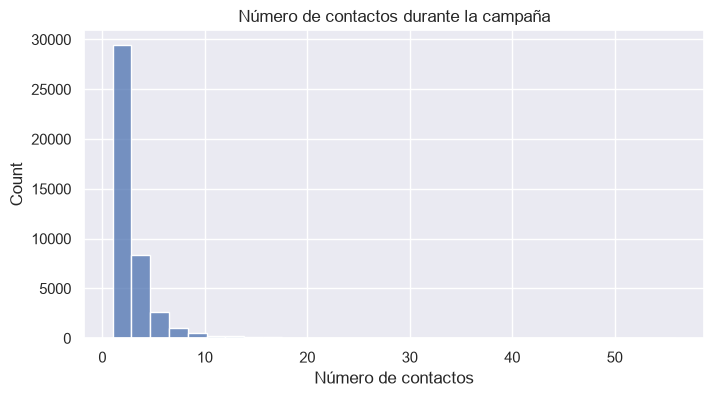

In [33]:
plt.figure(figsize=(8,4))
sns.histplot(data["campaign"], bins=30)
plt.title("Número de contactos durante la campaña")
plt.xlabel("Número de contactos")
plt.show()

## Análisis univariante

A continuación se lleva a cabo un análisis univariante. Nos centramos en las variables de principal interés, como son la edad, la duración de la interacción con el cliente, los ingrasos, el número de contactos realizados o las visitas mensuales de los clientes en la página web.

In [34]:
# Creamos una función para guardar gráficos

def guardar_grafico(nombre):
    plt.tight_layout() # Añadimos esta línea de código para evitar que se corten los títulos o las etiquetas de los ejes
    plt.savefig(f"C:/Users/U000000/Desktop/varios/ThePower/PROYECTO T8/images/{nombre}.png", dpi=300, bbox_inches="tight")
    plt.show()

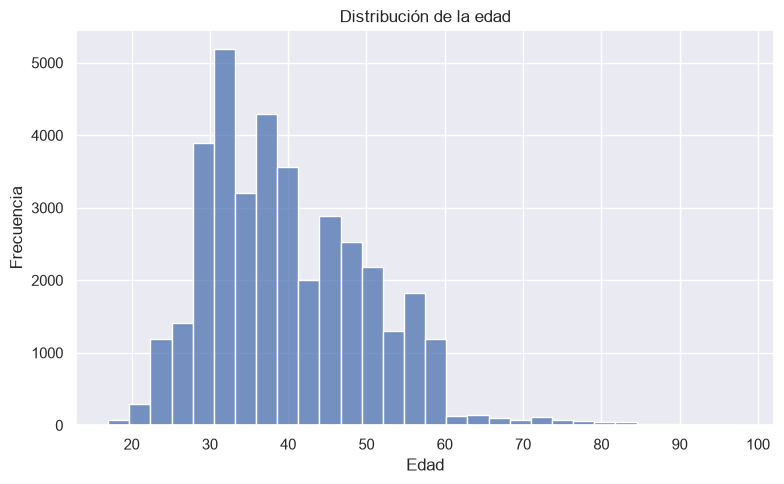

In [35]:
# Gráfico de distribución de la edad

plt.figure(figsize=(8,5))
sns.histplot(data["age"], bins=30)
plt.title("Distribución de la edad")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")

guardar_grafico("edad_histograma")

count    43000.000000
mean       257.739279
std        258.666033
min          0.000000
25%        102.000000
50%        179.000000
75%        319.000000
max       4918.000000
Name: duration, dtype: float64


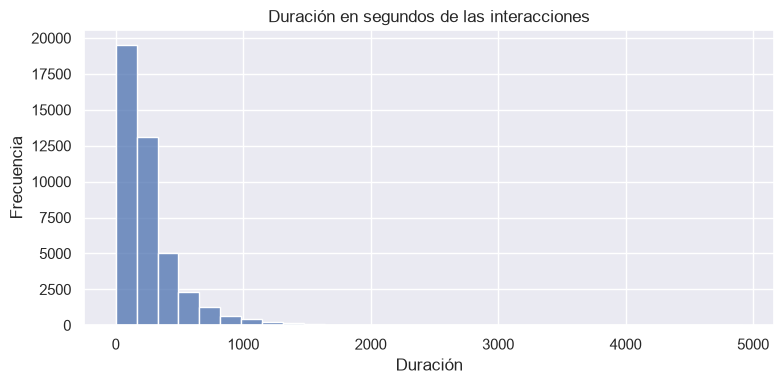

In [36]:
# Gráfico de distribución de la duración de los contactos

print(data["duration"].describe())

plt.figure(figsize=(8,4))

sns.histplot(data["duration"], bins=30)

plt.title("Duración en segundos de las interacciones")
plt.xlabel("Duración")
plt.ylabel("Frecuencia")

guardar_grafico("duracion_histograma")

count     43000.000000
mean      93241.200070
std       50498.316182
min        5841.000000
25%       49610.000000
50%       93050.500000
75%      136744.500000
max      180802.000000
Name: Income, dtype: float64


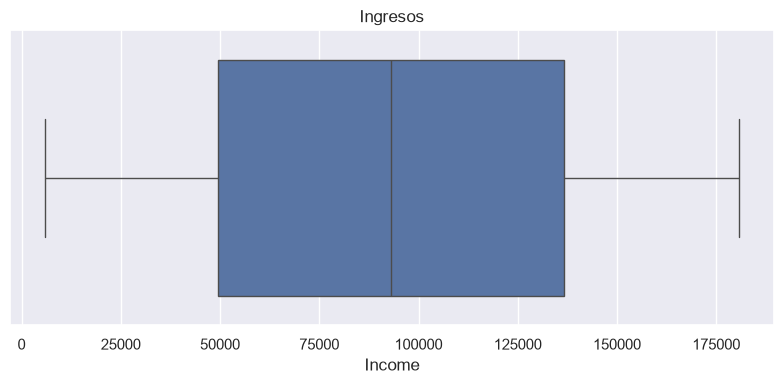

In [37]:
# Boxplot de los ingresos

print(data["Income"].describe())

plt.figure(figsize=(8,4))
sns.boxplot(x=data["Income"])
plt.title("Ingresos")

guardar_grafico("ingresos_boxplot")


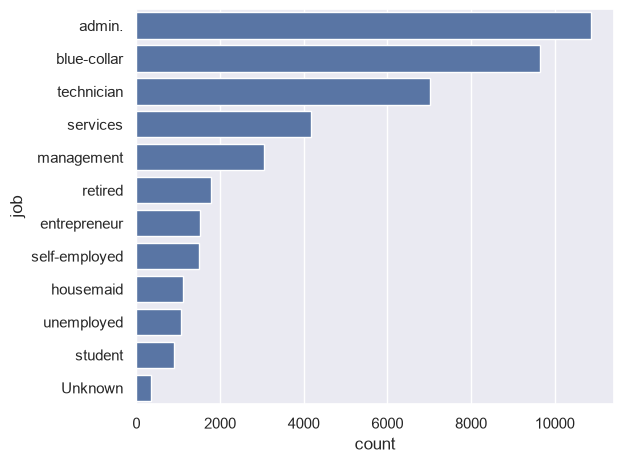

In [38]:
# Gráfico de barras de los empleos

sns.countplot(
    data=data,
    y="job",
    order=data["job"].value_counts().index
)

guardar_grafico("empleos_barras")

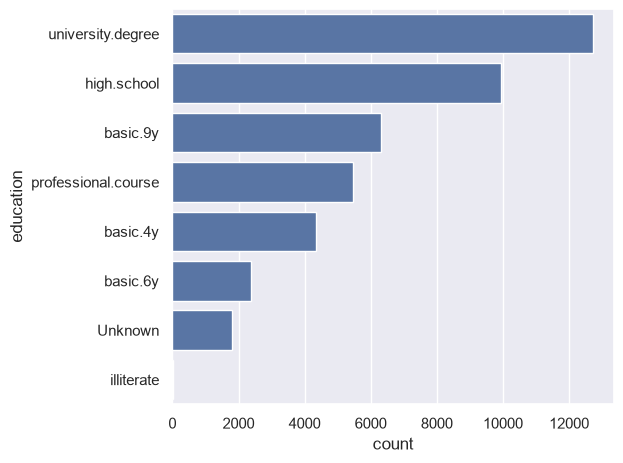

In [39]:
# Gráfico de barras de la educación

sns.countplot(
    data=data,
    y="education",
    order=data["education"].value_counts().index
)

guardar_grafico("educacion_barras")

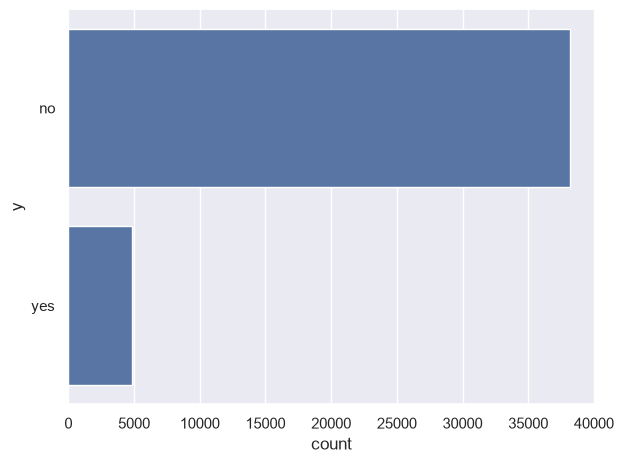

In [40]:
# Gráfico de barras de la suscripción

sns.countplot(
    data=data,
    y="y",
    order=data["y"].value_counts().index
)

guardar_grafico("suscripcion_barras")

## Análisis bivariante y correlaciones

Antes de realizar un análisis de la relación entre las variables vamos a crear tres nuevas variables:
- Grupos de edad
- Hijos (une "Kidhome" y "Teenhome")
- Préstamos (une "housing" y "loan")

Una vez hayamos creado estas variables, se realiza el análisis con respecto a la variable objetivo "y" de contratación.
También se analizarán las correlaciones de las variables numéricas.

count     37880
unique        6
top       25-35
freq      13705
Name: age_group, dtype: object
y                 no        yes
age_group                      
15-25      79.102564  20.897436
25-35      88.391098  11.608902
35-45      91.408964   8.591036
45-55      91.315301   8.684699
55-65      84.595397  15.404603
65+        53.993056  46.006944
count     37880
unique        6
top       25-35
freq      13705
Name: age_group, dtype: object


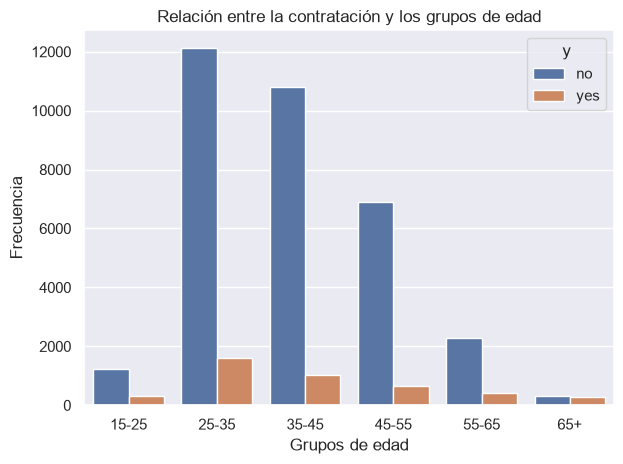

In [41]:
# Creación de la variable "age_group" y relación con la variable objetivo "y". Gráfico de contrataciones por grupo de edad

bins = [15, 25, 35, 45, 55, 65, 100]
labels = ["15-25", "25-35", "35-45", "45-55", "55-65", "65+"]

data["age_group"] = pd.cut(data["age"], bins=bins, labels=labels)
print(data["age_group"].describe())

print(pd.crosstab(data["age_group"], data["y"], normalize="index") * 100)

print(data["age_group"].describe())

sns.countplot(data=data, x="age_group", hue="y")
plt.title("Relación entre la contratación y los grupos de edad")
plt.xlabel("Grupos de edad")
plt.ylabel("Frecuencia")

guardar_grafico("contrataciones_grupoedad")

y                no        yes
children                      
0         88.262516  11.737484
1         89.204545  10.795455
2         88.474955  11.525045
3         88.983226  11.016774
4         88.547368  11.452632


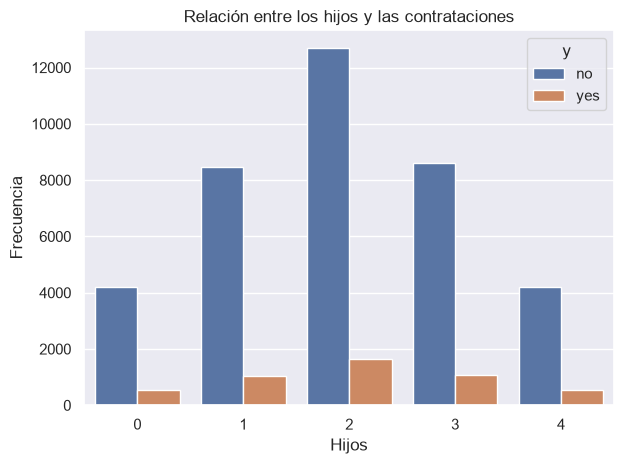

In [42]:
# Creación de la variable "children" y relación con la variable objetivo "y".
# Porcentajes de contrataciones en función del número de hijos y gráfico de barras

data["children"] = data["Kidhome"] + data["Teenhome"]

print(pd.crosstab(data["children"], data["y"], normalize="index") * 100)

sns.countplot(data=data, x="children", hue="y")
plt.title("Relación entre los hijos y las contrataciones")
plt.xlabel("Hijos")
plt.ylabel("Frecuencia")

guardar_grafico("contrataciones_hijos")
 

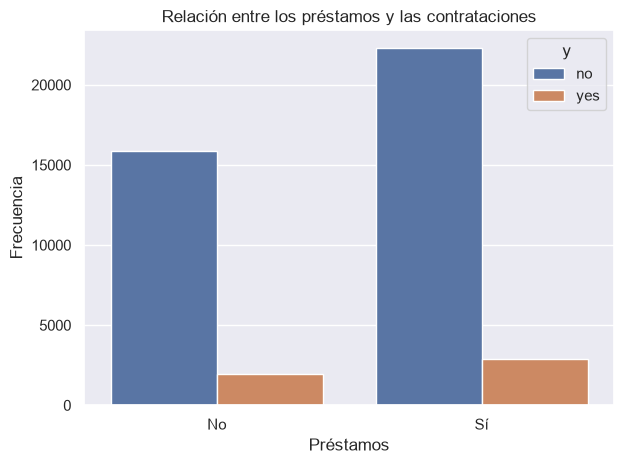

y                no        yes
has_loan                      
No        89.116524  10.883476
Sí        88.464898  11.535102
y               no        yes
housing                      
No       89.145615  10.854385
Sí       88.372300  11.627700
Unknown  88.888889  11.111111
y               no        yes
loan                         
No       88.665990  11.334010
Sí       89.084507  10.915493
Unknown  88.888889  11.111111


In [43]:
# Creación de la variable "has_loan" y relación con la variable objetivo "y"

data["has_loan"] = np.where(
    (data["housing"] == "Sí") | (data["loan"] == "Sí"),
    "Sí",
    "No"
)

sns.countplot(data=data, x="has_loan", hue="y")
plt.title("Relación entre los préstamos y las contrataciones")
plt.xlabel("Préstamos")
plt.ylabel("Frecuencia")

guardar_grafico("contrataciones_prestamos")

# Porcentajes de contrataciones en función de si tienen préstamos o no.
# Contrastamos además si hay comportamientos diferentes en función del préstamos, pero no vemos diferencias.

print(pd.crosstab(data["has_loan"], data["y"], normalize="index") * 100)
print(pd.crosstab(data["housing"], data["y"], normalize="index") * 100)
print(pd.crosstab(data["loan"], data["y"], normalize="index") * 100)

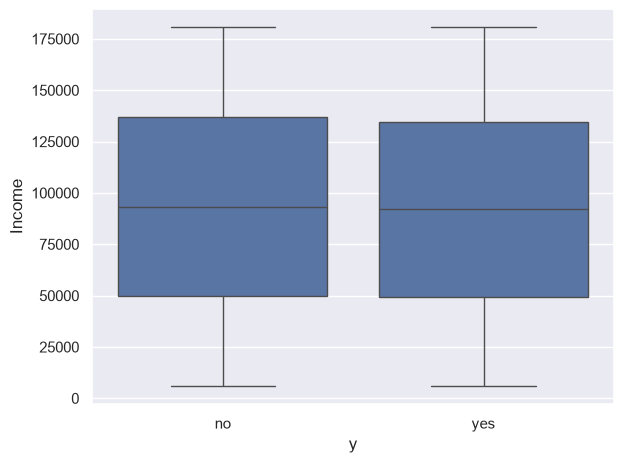

In [44]:
# Comparación entre los ingresos y la contratación.
# No se observan diferencias de comportamiento entre los grupos.

sns.boxplot(
    data=data,
    x="y",
    y="Income"
)

guardar_grafico("contrataciones_ingresos")

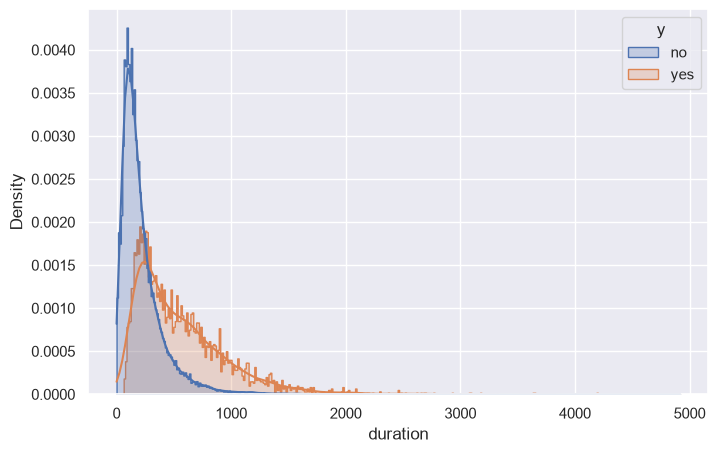

,count,mean,std,min,25%,50%,75%,max
y,,,,,,,,
no,38156.0,220.430208,207.121495,0.0,95.0,163.0,278.0,4918.0
yes,4844.0,551.621387,398.398264,63.0,253.0,449.0,740.0,4199.0


In [45]:
# Comparación entre la duración de las llamadas y la contratación.
# Sí se observan diferencias de comportamiento entre los grupos.

plt.figure(figsize=(8,5))

sns.histplot(
    data=data,
    x="duration",
    hue="y",
    kde=True,
    element="step",
    stat="density",
    common_norm=False
)

plt.show()

# Comprobamos numéricamente estas diferencias

data.groupby("y")["duration"].describe()

y                 no    yes
job                        
Unknown        88.70  11.30
admin.         86.99  13.01
blue-collar    93.11   6.89
entrepreneur   91.72   8.28
housemaid      90.12   9.88
management     88.79  11.21
retired        74.80  25.20
self-employed  89.19  10.81
services       91.93   8.07
student        68.66  31.34
technician     89.15  10.85
unemployed     85.61  14.39


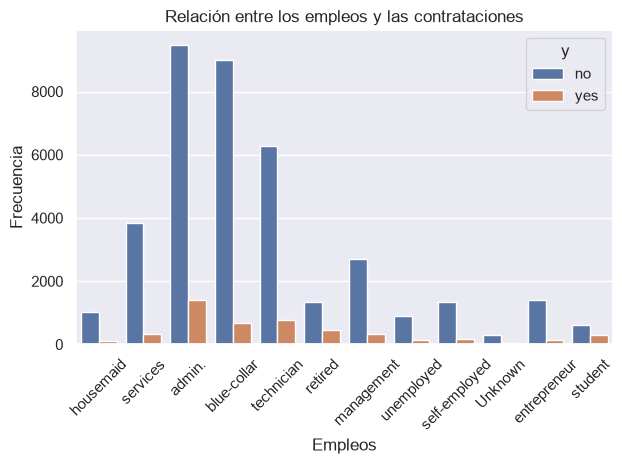

In [55]:
# Comparación entre el empleo y la contratación.
# Sí se observan diferencias de comportamiento entre los grupos.

tabla_job = (pd.crosstab(data["job"], data["y"], normalize="index") * 100).round(2)
print(tabla_job)

sns.countplot(data=data, x="job", hue="y")
plt.title("Relación entre los empleos y las contrataciones")
plt.xlabel("Empleos")
plt.ylabel("Frecuencia")

plt.xticks(rotation=45)

guardar_grafico("contrataciones_empleos")

y                       no    yes
education                        
Unknown              85.56  14.44
basic.4y             89.72  10.28
basic.6y             91.87   8.13
basic.9y             92.19   7.81
high.school          89.16  10.84
illiterate           77.78  22.22
professional.course  88.68  11.32
university.degree    86.26  13.74


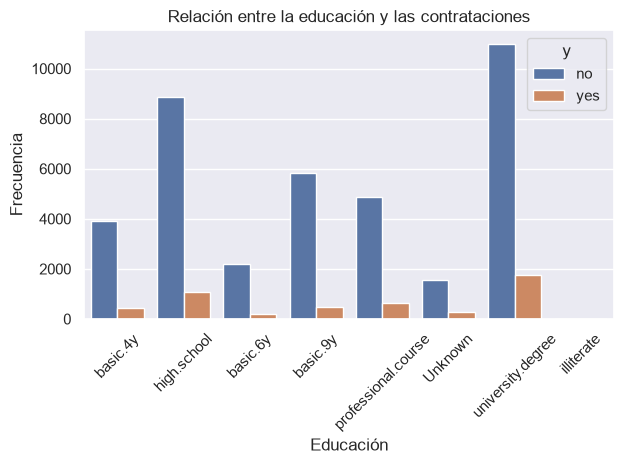

In [56]:
# Comparación entre la educación y la contratación.
# Sí se observan diferencias de comportamiento entre los grupos.

tabla_education = (pd.crosstab(data["education"], data["y"], normalize="index") * 100).round(2)
print(tabla_education)

sns.countplot(data=data, x="education", hue="y")
plt.title("Relación entre la educación y las contrataciones")
plt.xlabel("Educación")
plt.ylabel("Frecuencia")

plt.xticks(rotation=45)

guardar_grafico("contrataciones_educacion")

y                     no    yes
NumWebVisitsMonth              
1                  88.76  11.24
2                  89.60  10.40
3                  88.69  11.31
4                  88.50  11.50
5                  88.08  11.92
6                  88.72  11.28
7                  89.43  10.57
8                  89.18  10.82
9                  88.20  11.80
10                 87.68  12.32
11                 89.76  10.24
12                 88.63  11.37
13                 86.95  13.05
14                 88.90  11.10
15                 91.01   8.99
16                 88.60  11.40
17                 88.91  11.09
18                 88.60  11.40
19                 87.86  12.14
20                 88.75  11.25
21                 88.49  11.51
22                 87.92  12.08
23                 88.66  11.34
24                 89.11  10.89
25                 90.06   9.94
26                 87.33  12.67
27                 88.58  11.42
28                 90.04   9.96
29                 88.99  11.01
30      

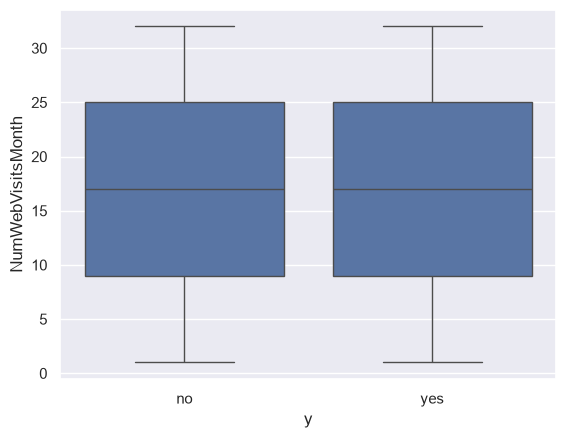

In [48]:
sns.boxplot(data=data, x="y", y="NumWebVisitsMonth")

tabla_visitas = (pd.crosstab(data["NumWebVisitsMonth"], data["y"], normalize="index") * 100).round(2)
print(tabla_visitas)

y             no    yes
campaign               
1          86.98  13.02
2          88.52  11.48
3          89.18  10.82
4          90.71   9.29
5          92.58   7.42
6          92.29   7.71
7          93.92   6.08
8          95.22   4.78
9          94.46   5.54
10         94.49   5.51
11         93.44   6.56
12         97.69   2.31
13         95.74   4.26
14         98.63   1.37
15         96.08   3.92
16        100.00   0.00
17         93.44   6.56
18        100.00   0.00
19        100.00   0.00
20        100.00   0.00
21        100.00   0.00
22        100.00   0.00
23         95.00   5.00
24        100.00   0.00
25        100.00   0.00
26        100.00   0.00
27        100.00   0.00
28        100.00   0.00
29        100.00   0.00
30        100.00   0.00
31        100.00   0.00
32        100.00   0.00
33        100.00   0.00
34        100.00   0.00
35        100.00   0.00
37        100.00   0.00
39        100.00   0.00
40        100.00   0.00
41        100.00   0.00
42        100.00

,count,mean,std,min,25%,50%,75%,max
y,,,,,,,,
no,38156.0,2.632797,2.876537,1.0,1.0,2.0,3.0,56.0
yes,4844.0,2.050784,1.657519,1.0,1.0,2.0,2.0,23.0


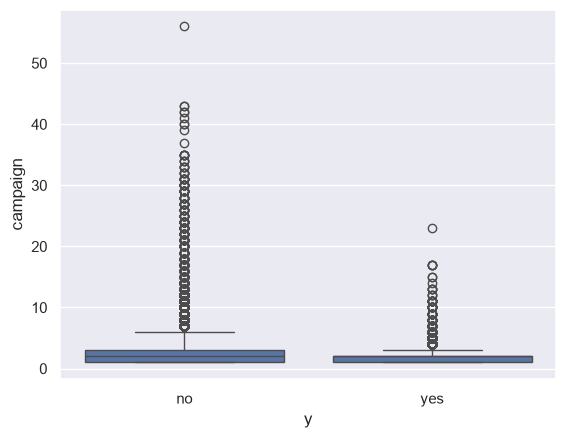

In [ ]:
# Número de contactos realizados durante la campaña

sns.boxplot(data=data, x="y", y="campaign")
tabla_campaign = (pd.crosstab(data["campaign"], data["y"], normalize="index") * 100).round(2)
print(tabla_campaign)

data.groupby("y")["campaign"].describe()


y             no    yes
previous               
0          91.18   8.82
1          78.90  21.10
2          53.44  46.56
3          39.66  60.34
4          45.33  54.67
5          25.00  75.00
6          40.00  60.00
7         100.00   0.00


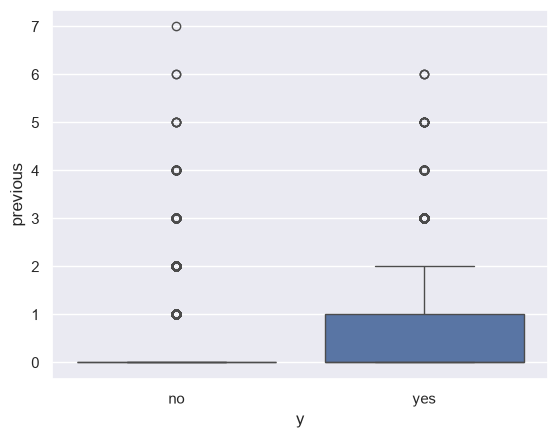

In [ ]:
# Contactos previos

sns.boxplot(data=data, x="y", y="previous")

tabla_previous = (pd.crosstab(data["previous"], data["y"], normalize="index") * 100).round(2)
print(tabla_previous)

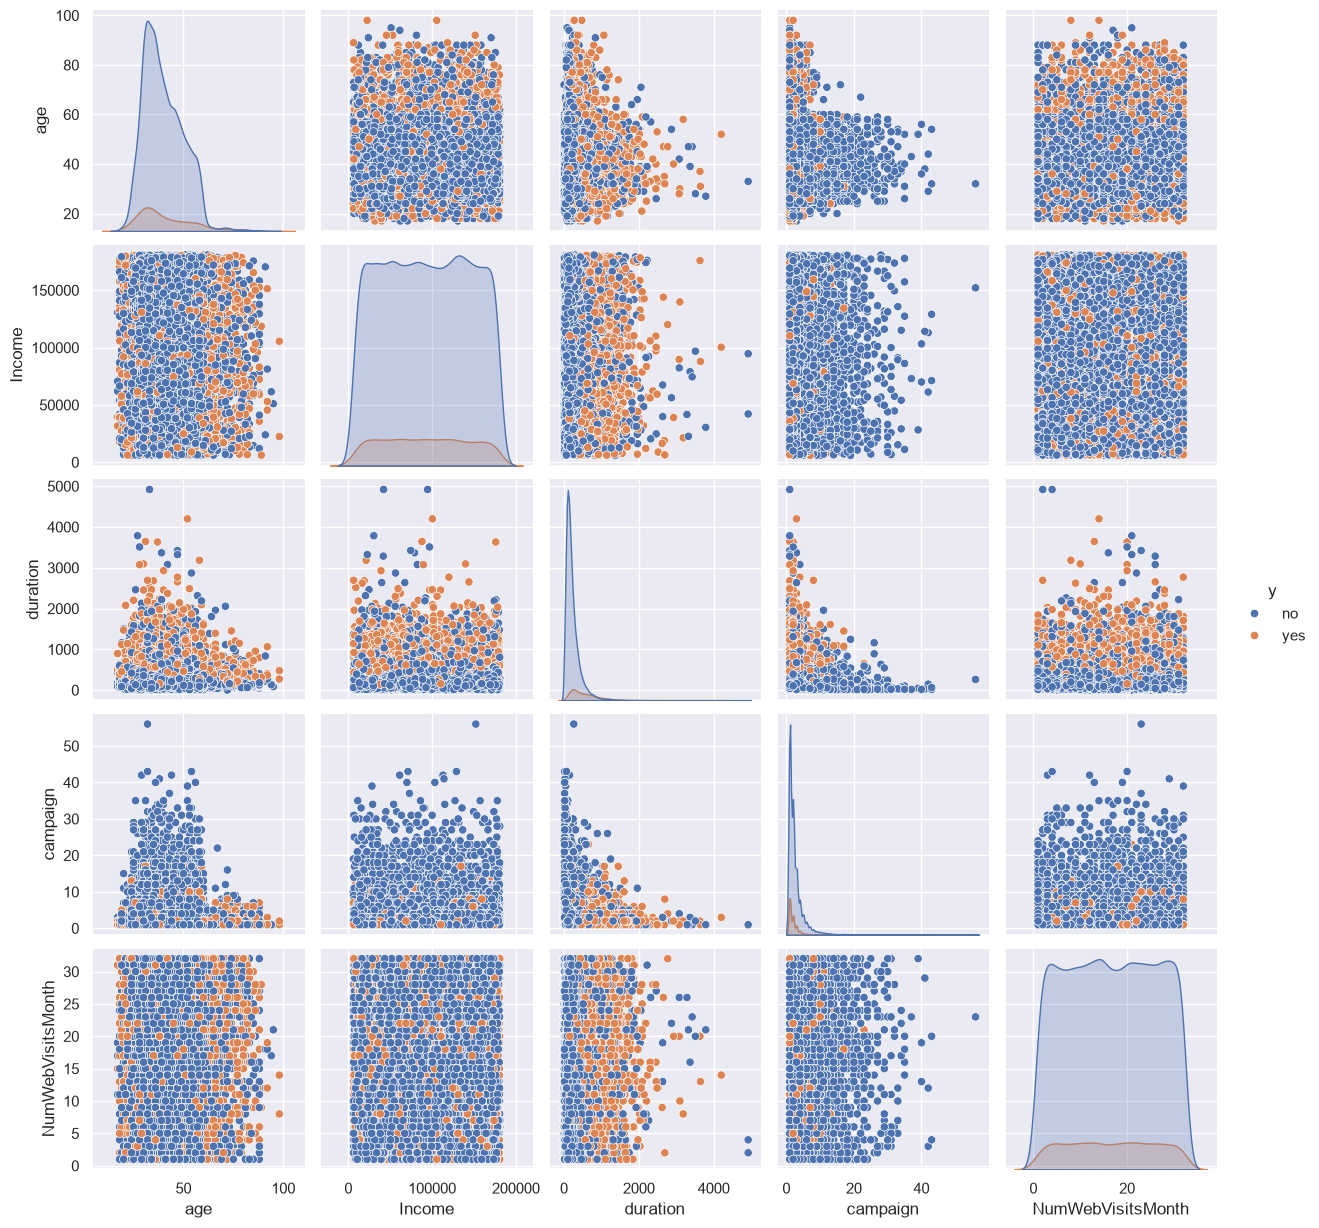

In [ ]:
# Paiplot para analizar las relaciones lineales entre algunas variables

sns.pairplot(
    data[
        [
            "age",
            "Income",
            "duration",
            "campaign",
            "NumWebVisitsMonth",
            "y"
        ]
    ],
    hue="y"
)

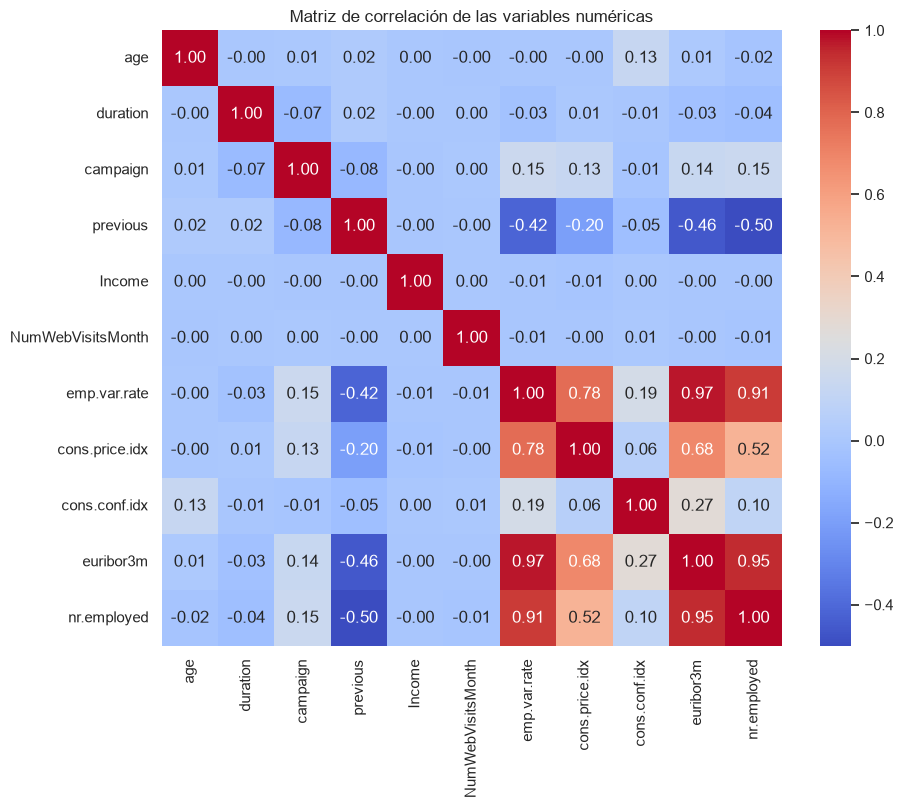

In [ ]:
# Correlación de las variables numéricas

numericas = [
    "age",
    "duration",
    "campaign",
    "previous",
    "Income",
    "NumWebVisitsMonth",
    "emp.var.rate",
    "cons.price.idx",
    "cons.conf.idx",
    "euribor3m",
    "nr.employed"
]

corr = data[numericas].corr()


plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matriz de correlación de las variables numéricas")
plt.show()
